In [24]:
import pandas as pd
import requests
import json

import matplotlib.pyplot as plt

In [25]:
prices_df = pd.read_csv('apri_ap_crpouta$defaultview_linear.csv')
print(prices_df.columns)
prices_df.head()


Index(['DATAFLOW', 'LAST UPDATE', 'freq', 'currency', 'prod_veg', 'geo',
       'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'],
      dtype='object')


,DATAFLOW,LAST UPDATE,freq,currency,prod_veg,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:APRI_AP_CRPOUTA$DEFAULTVIEW(1.0),15/05/25 11:00:00,Annual,Euro,Soft wheat - prices per 100 kg,Austria,2015,13.72,NaN,NaN
1,ESTAT:APRI_AP_CRPOUTA$DEFAULTVIEW(1.0),15/05/25 11:00:00,Annual,Euro,Soft wheat - prices per 100 kg,Austria,2016,11.55,NaN,NaN
2,ESTAT:APRI_AP_CRPOUTA$DEFAULTVIEW(1.0),15/05/25 11:00:00,Annual,Euro,Soft wheat - prices per 100 kg,Austria,2017,14.46,NaN,NaN
3,ESTAT:APRI_AP_CRPOUTA$DEFAULTVIEW(1.0),15/05/25 11:00:00,Annual,Euro,Soft wheat - prices per 100 kg,Austria,2018,15.41,NaN,NaN
4,ESTAT:APRI_AP_CRPOUTA$DEFAULTVIEW(1.0),15/05/25 11:00:00,Annual,Euro,Soft wheat - prices per 100 kg,Austria,2019,14.63,NaN,NaN


In [26]:
prices_df = prices_df.drop(['DATAFLOW','LAST UPDATE','freq','OBS_FLAG','CONF_STATUS'],axis=1)
prices_df.head(20)


,currency,prod_veg,geo,TIME_PERIOD,OBS_VALUE
0,Euro,Soft wheat - prices per 100 kg,Austria,2015,13.72
1,Euro,Soft wheat - prices per 100 kg,Austria,2016,11.55
2,Euro,Soft wheat - prices per 100 kg,Austria,2017,14.46
3,Euro,Soft wheat - prices per 100 kg,Austria,2018,15.41
4,Euro,Soft wheat - prices per 100 kg,Austria,2019,14.63
5,Euro,Soft wheat - prices per 100 kg,Austria,2020,14.88
6,Euro,Soft wheat - prices per 100 kg,Austria,2021,22.65
7,Euro,Soft wheat - prices per 100 kg,Austria,2022,28.05
8,Euro,Soft wheat - prices per 100 kg,Austria,2023,17.90
9,Euro,Soft wheat - prices per 100 kg,Austria,2024,17.60


In [27]:
austria_year = (prices_df.geo == "Hungary") & (prices_df.TIME_PERIOD == 2015)
prices_df.loc[austria_year,:]

,currency,prod_veg,geo,TIME_PERIOD,OBS_VALUE
117,Euro,Soft wheat - prices per 100 kg,Hungary,2015,15.58
314,Euro,Durum wheat - prices per 100 kg,Hungary,2015,22.56
461,Euro,Rye - prices per 100 kg,Hungary,2015,12.61
651,Euro,Barley - prices per 100 kg,Hungary,2015,13.51
880,Euro,Feed barley - prices per 100 kg,Hungary,2015,13.34
1116,National currency,Soft wheat - prices per 100 kg,Hungary,2015,4830.00
1314,National currency,Durum wheat - prices per 100 kg,Hungary,2015,6994.00
1461,National currency,Rye - prices per 100 kg,Hungary,2015,3908.00
1652,National currency,Barley - prices per 100 kg,Hungary,2015,4189.00
1881,National currency,Feed barley - prices per 100 kg,Hungary,2015,4135.00


In [28]:
prices_df.drop(prices_df[prices_df['currency'] == 'National currency'].index, inplace=True)
prices_df['currency'].unique()

array(['Euro'], dtype=object)

In [29]:
prices_df['prod_veg'].unique()

array(['Soft wheat - prices per 100 kg',
       'Durum wheat - prices per 100 kg', 'Rye - prices per 100 kg',
       'Barley - prices per 100 kg', 'Feed barley - prices per 100 kg'],
      dtype=object)

In [30]:
prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   currency     999 non-null    object 
 1   prod_veg     999 non-null    object 
 2   geo          999 non-null    object 
 3   TIME_PERIOD  999 non-null    int64  
 4   OBS_VALUE    960 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 39.2+ KB


In [31]:
prices_df.duplicated().sum()
prices_df.isna().sum()

currency        0
prod_veg        0
geo             0
TIME_PERIOD     0
OBS_VALUE      39
dtype: int64

In [32]:
prices_df[prices_df.isnull().any(axis=1)]

,currency,prod_veg,geo,TIME_PERIOD,OBS_VALUE
154,Euro,Soft wheat - prices per 100 kg,Luxembourg,2021,NaN
155,Euro,Soft wheat - prices per 100 kg,Luxembourg,2022,NaN
156,Euro,Soft wheat - prices per 100 kg,Luxembourg,2023,NaN
157,Euro,Soft wheat - prices per 100 kg,Luxembourg,2024,NaN
253,Euro,Durum wheat - prices per 100 kg,Belgium,2015,NaN
274,Euro,Durum wheat - prices per 100 kg,Czechia,2015,NaN
335,Euro,Durum wheat - prices per 100 kg,Luxembourg,2015,NaN
336,Euro,Durum wheat - prices per 100 kg,Luxembourg,2022,NaN
337,Euro,Durum wheat - prices per 100 kg,Luxembourg,2023,NaN
338,Euro,Durum wheat - prices per 100 kg,Luxembourg,2024,NaN


In [33]:
prices_df[prices_df["OBS_VALUE"].isnull()]["geo"].value_counts()

geo
Luxembourg    20
Ireland       11
Slovenia       4
Belgium        2
Czechia        1
Austria        1
Name: count, dtype: int64

In [34]:
len(prices_df[prices_df["geo"] == "Luxembourg"])
len(prices_df[prices_df["geo"] == "Ireland"])
len(prices_df[prices_df["geo"] == "Belgium"])

32

### Note: Half the data for Luxembourg and Ireland are missing; substituted with median for the null values (possible outside influence/biases)

In [35]:
#fill in null values with median
prices_df['OBS_VALUE'] = prices_df.groupby('geo')['OBS_VALUE'].transform(lambda x: x.fillna(x.median()))

prices_df.head()

,currency,prod_veg,geo,TIME_PERIOD,OBS_VALUE
0,Euro,Soft wheat - prices per 100 kg,Austria,2015,13.72
1,Euro,Soft wheat - prices per 100 kg,Austria,2016,11.55
2,Euro,Soft wheat - prices per 100 kg,Austria,2017,14.46
3,Euro,Soft wheat - prices per 100 kg,Austria,2018,15.41
4,Euro,Soft wheat - prices per 100 kg,Austria,2019,14.63


In [37]:
import plotly.express as px

fig = px.line(
    prices_df,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    color="geo",
    markers=True,
    title="crop price by country",
    labels={
        "TIME_PERIOD": "Year",
        "OBS_VALUE": "price",
        "geo": "Country/area",
    },
)

fig.show()

In [38]:
import plotly.express as px

fig = px.line(
    prices_df,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    color="prod_veg",
    markers=True,
    title="crop price by crop",
    labels={
        "TIME_PERIOD": "Year",
        "OBS_VALUE": "price",
        "prod_veg": "crop",
    },
)

fig.show()

In [39]:
belgium = prices_df[prices_df["geo"] == "Belgium"]

fig = px.line(
    belgium,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    color="prod_veg",
    title="Belgium Crop Prices Over Time"
)

fig.show()

In [277]:
# df.head(50)
# df["geo"]["belgium"]

In [42]:
# lat, lon of each capital city
eu_countries = {
    "Austria": (48.21, 16.37),
    "Belgium": (50.85, 4.35),
    "Bulgaria": (42.70, 23.32),
    "Croatia": (45.81, 15.98),
    "Cyprus": (35.17, 33.36),
    "Czechia": (50.08, 14.43),
    "Denmark": (55.68, 12.57),
    "Estonia": (59.44, 24.75),
    "Finland": (60.17, 24.94),
    "France": (48.85, 2.35),
    "Germany": (52.52, 13.41),
    "Greece": (37.98, 23.72),
    "Hungary": (47.50, 19.04),
    "Ireland": (53.35, -6.26),
    "Italy": (41.90, 12.50),
    "Latvia": (56.95, 24.10),
    "Lithuania": (54.68, 25.28),
    "Luxembourg": (49.61, 6.13),
    "Malta": (35.90, 14.51),
    "Netherlands": (52.37, 4.90),
    "Poland": (52.23, 21.01),
    "Portugal": (38.72, -9.14),
    "Romania": (44.43, 26.10),
    "Slovakia": (48.15, 17.11),
    "Slovenia": (46.05, 14.51),
    "Spain": (40.42, -3.70),
    "Sweden": (59.33, 18.07)
}

In [43]:
import requests
import pandas as pd

def get_weather(lat, lon, country, year):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "daily": "temperature_2m_mean,precipitation_sum",
        "timezone": "auto"
    }

    r = requests.get(url, params=params)
    data = r.json()
    df = pd.DataFrame(data["daily"])
    print(df)

    df["time"] = pd.to_datetime(df["time"])
    df["year"] = df["time"].dt.year

    yearly = df.groupby("year").agg({
        "temperature_2m_mean": "mean",
        "precipitation_sum": "sum"
    }).reset_index()

    yearly["geo"] = country

    return yearly

In [44]:
all_weather = []

for country, (lat, lon) in eu_countries.items():
    for year in range(2015, 2025):
        df = get_weather(lat, lon, country, year)
        all_weather.append(df)

weather_df = pd.concat(all_weather, ignore_index=True)

           time  temperature_2m_mean  precipitation_sum
0    2015-01-01                  0.4                0.1
1    2015-01-02                  2.6                0.9
2    2015-01-03                  3.2                3.1
3    2015-01-04                  2.0                8.2
4    2015-01-05                  1.5                4.1
..          ...                  ...                ...
360  2015-12-27                  3.0                0.0
361  2015-12-28                  2.4                0.0
362  2015-12-29                  2.6                0.0
363  2015-12-30                  0.1                0.2
364  2015-12-31                 -3.2                0.0

[365 rows x 3 columns]
           time  temperature_2m_mean  precipitation_sum
0    2016-01-01                 -1.9                0.0
1    2016-01-02                 -2.0                0.0
2    2016-01-03                 -5.3                0.0
3    2016-01-04                 -6.8                0.0
4    2016-01-05         

In [312]:
print(weather_df)

     year  temperature_2m_mean  precipitation_sum      geo
0    2015            11.941370              561.2  Austria
1    2016            11.251913              704.2  Austria
2    2017            11.234795              527.5  Austria
3    2018            12.166027              614.9  Austria
4    2019            12.056712              614.0  Austria
..    ...                  ...                ...      ...
265  2020             8.789617              612.5   Sweden
266  2021             7.089863              671.4   Sweden
267  2022             7.646027              601.5   Sweden
268  2023             7.100000              772.0   Sweden
269  2024             7.955464              647.9   Sweden

[270 rows x 4 columns]


In [45]:
prices_df["TIME_PERIOD"] = prices_df["TIME_PERIOD"].astype(int)
prices_df = prices_df.rename(columns={"TIME_PERIOD": "year"})
prices_df = prices_df.rename(columns={"OBS_VALUE": "selling_price"})

In [46]:
merged_df = prices_df.merge(
    weather_df,
    on=["geo", "year"],
    how="left"
)

In [47]:
merged_df['prod_veg'].unique()
print(merged_df)

    currency                         prod_veg       geo  year  selling_price  \
0       Euro   Soft wheat - prices per 100 kg   Austria  2015          13.72   
1       Euro   Soft wheat - prices per 100 kg   Austria  2016          11.55   
2       Euro   Soft wheat - prices per 100 kg   Austria  2017          14.46   
3       Euro   Soft wheat - prices per 100 kg   Austria  2018          15.41   
4       Euro   Soft wheat - prices per 100 kg   Austria  2019          14.63   
..       ...                              ...       ...   ...            ...   
994     Euro  Feed barley - prices per 100 kg  Slovakia  2020          12.42   
995     Euro  Feed barley - prices per 100 kg  Slovakia  2021          15.51   
996     Euro  Feed barley - prices per 100 kg  Slovakia  2022          24.43   
997     Euro  Feed barley - prices per 100 kg  Slovakia  2023          16.64   
998     Euro  Feed barley - prices per 100 kg  Slovakia  2024          17.89   

     temperature_2m_mean  precipitation

In [48]:
merged_df["prod_veg"] = merged_df["prod_veg"].str.replace(r"\s-\sprices.*", "", regex=True)
merged_df.head()

,currency,prod_veg,geo,year,selling_price,temperature_2m_mean,precipitation_sum
0,Euro,Soft wheat,Austria,2015,13.72,11.941370,561.2
1,Euro,Soft wheat,Austria,2016,11.55,11.251913,704.2
2,Euro,Soft wheat,Austria,2017,14.46,11.234795,527.5
3,Euro,Soft wheat,Austria,2018,15.41,12.166027,614.9
4,Euro,Soft wheat,Austria,2019,14.63,12.056712,614.0


In [49]:
merged_df

,currency,prod_veg,geo,year,selling_price,temperature_2m_mean,precipitation_sum
0,Euro,Soft wheat,Austria,2015,13.72,11.941370,561.2
1,Euro,Soft wheat,Austria,2016,11.55,11.251913,704.2
2,Euro,Soft wheat,Austria,2017,14.46,11.234795,527.5
3,Euro,Soft wheat,Austria,2018,15.41,12.166027,614.9
4,Euro,Soft wheat,Austria,2019,14.63,12.056712,614.0
...,...,...,...,...,...,...,...
994,Euro,Feed barley,Slovakia,2020,12.42,11.560383,716.9
995,Euro,Feed barley,Slovakia,2021,15.51,10.789315,611.2
996,Euro,Feed barley,Slovakia,2022,24.43,11.939178,527.6
997,Euro,Feed barley,Slovakia,2023,16.64,12.217260,735.4


In [50]:
merged_df.isna().sum()

currency                0
prod_veg                0
geo                     0
year                    0
selling_price           0
temperature_2m_mean    10
precipitation_sum      10
dtype: int64

In [51]:
merged_df[merged_df.isnull().any(axis=1)]

,currency,prod_veg,geo,year,selling_price,temperature_2m_mean,precipitation_sum
238,Euro,Soft wheat,United Kingdom,2015,17.01,NaN,NaN
239,Euro,Soft wheat,United Kingdom,2016,14.68,NaN,NaN
240,Euro,Soft wheat,United Kingdom,2017,16.62,NaN,NaN
241,Euro,Soft wheat,United Kingdom,2018,18.49,NaN,NaN
242,Euro,Soft wheat,United Kingdom,2019,18.11,NaN,NaN
761,Euro,Barley,United Kingdom,2015,14.41,NaN,NaN
762,Euro,Barley,United Kingdom,2016,12.46,NaN,NaN
763,Euro,Barley,United Kingdom,2017,13.77,NaN,NaN
764,Euro,Barley,United Kingdom,2018,16.75,NaN,NaN
765,Euro,Barley,United Kingdom,2019,14.67,NaN,NaN


In [52]:
merged_df["geo"].unique()

array(['Austria', 'Belgium', 'Bulgaria', 'Cyprus', 'Czechia', 'Germany',
       'Denmark', 'Estonia', 'Greece', 'Spain', 'Finland', 'France',
       'Croatia', 'Hungary', 'Ireland', 'Italy', 'Lithuania',
       'Luxembourg', 'Latvia', 'Netherlands', 'Poland', 'Portugal',
       'Romania', 'Sweden', 'Slovenia', 'Slovakia', 'United Kingdom'],
      dtype=object)

In [53]:
merged_df = merged_df[~merged_df["geo"].isin(["United Kingdom", "Kosovo*"])]
merged_df['currency'] = merged_df['currency'].replace('National currency','Euro')
merged_df

C:\Users\npste\AppData\Local\Temp\ipykernel_45228\190890312.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['currency'] = merged_df['currency'].replace('National currency','Euro')


,currency,prod_veg,geo,year,selling_price,temperature_2m_mean,precipitation_sum
0,Euro,Soft wheat,Austria,2015,13.72,11.941370,561.2
1,Euro,Soft wheat,Austria,2016,11.55,11.251913,704.2
2,Euro,Soft wheat,Austria,2017,14.46,11.234795,527.5
3,Euro,Soft wheat,Austria,2018,15.41,12.166027,614.9
4,Euro,Soft wheat,Austria,2019,14.63,12.056712,614.0
...,...,...,...,...,...,...,...
994,Euro,Feed barley,Slovakia,2020,12.42,11.560383,716.9
995,Euro,Feed barley,Slovakia,2021,15.51,10.789315,611.2
996,Euro,Feed barley,Slovakia,2022,24.43,11.939178,527.6
997,Euro,Feed barley,Slovakia,2023,16.64,12.217260,735.4


In [54]:
merged_df.isna().sum()

currency               0
prod_veg               0
geo                    0
year                   0
selling_price          0
temperature_2m_mean    0
precipitation_sum      0
dtype: int64

In [55]:
merged_df["currency"].unique()

array(['Euro'], dtype=object)

In [56]:
import plotly.express as px

fig = px.histogram(merged_df, x='selling_price', nbins=40, title='Selling price distribution')
fig.show()

<Axes: >

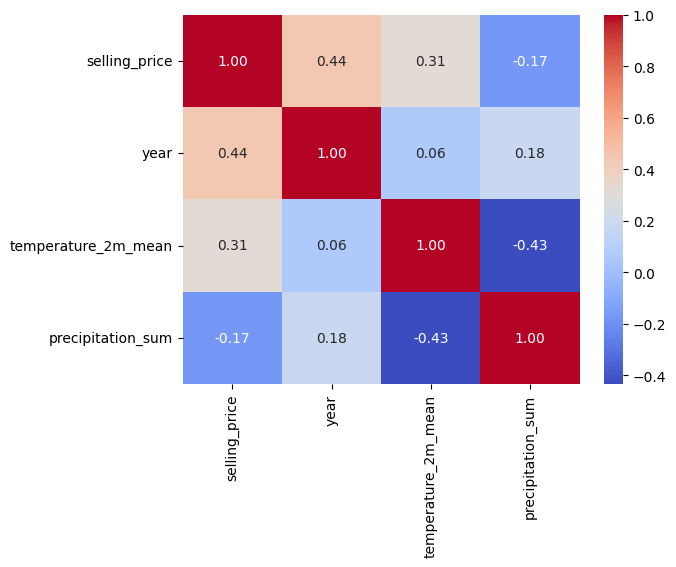

In [57]:
import seaborn as sns

sns.heatmap(merged_df[['selling_price','year',
  'temperature_2m_mean','precipitation_sum']].corr(),
  annot=True, fmt='.2f', cmap='coolwarm')

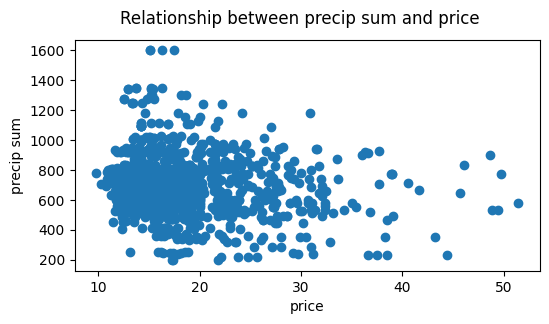

In [58]:
plt.scatter(merged_df['selling_price'], merged_df['precipitation_sum'])
plt.xlabel('price')
plt.ylabel('precip sum')
plt.suptitle('Relationship between precip sum and price')
plt.gcf().set_size_inches(6, 3)

In [59]:
merged_df[['selling_price', 'precipitation_sum']].describe()

,selling_price,precipitation_sum
count,989.000000,989.000000
mean,18.737983,697.579575
std,6.276703,212.781518
min,9.730000,195.900000
25%,14.370000,561.200000
50%,16.810000,680.700000
75%,21.550000,804.200000
max,51.450000,1601.000000


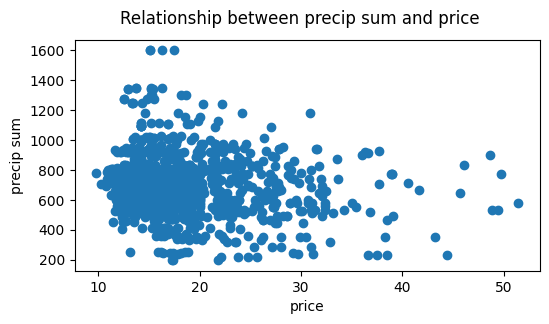

In [63]:
plt.scatter(merged_df['selling_price'], merged_df['precipitation_sum'])
plt.xlabel('price')
plt.ylabel('precip sum')
plt.suptitle('Relationship between precip sum and price')
plt.gcf().set_size_inches(6, 3)

<Axes: >

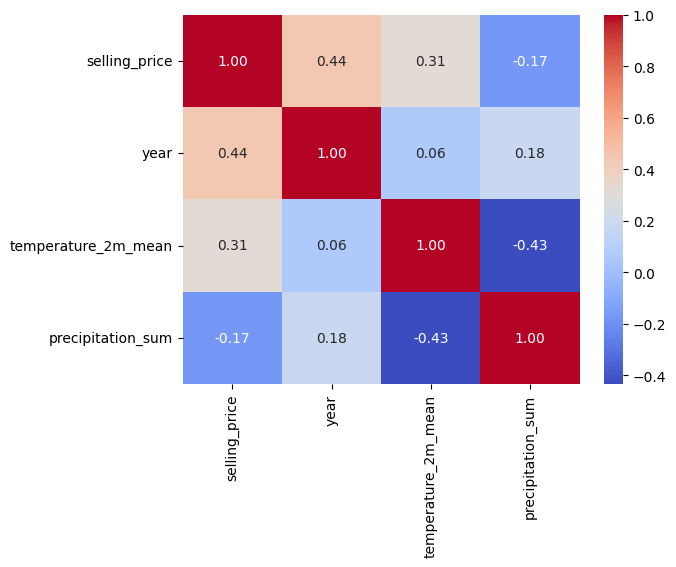

In [64]:
sns.heatmap(merged_df[['selling_price','year',
  'temperature_2m_mean','precipitation_sum']].corr(),
  annot=True, fmt='.2f', cmap='coolwarm')

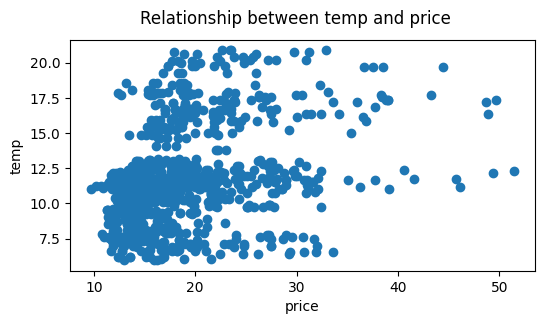

In [66]:
plt.scatter(merged_df['selling_price'], merged_df['temperature_2m_mean'])
plt.xlabel('price')
plt.ylabel('temp')
plt.suptitle('Relationship between temp and price')
plt.gcf().set_size_inches(6, 3)

<Axes: >

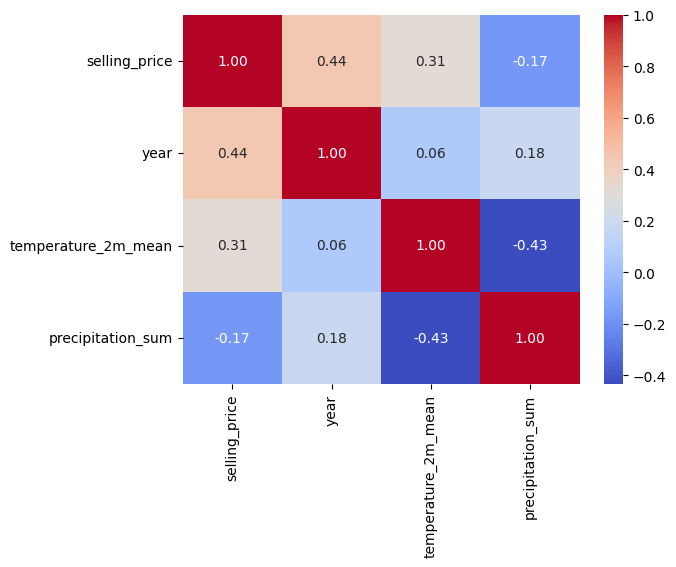

In [67]:
sns.heatmap(merged_df[['selling_price','year',
  'temperature_2m_mean','precipitation_sum']].corr(),
  annot=True, fmt='.2f', cmap='coolwarm')

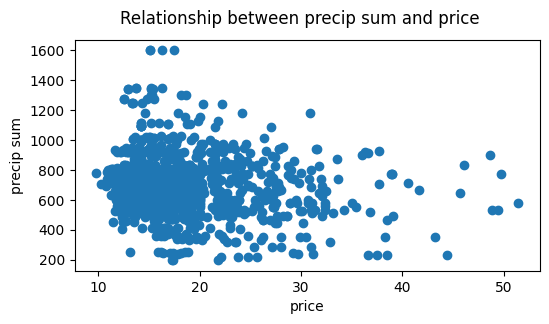

In [68]:
plt.scatter(merged_df['selling_price'], merged_df['precipitation_sum'])
plt.xlabel('price')
plt.ylabel('precip sum')
plt.suptitle('Relationship between precip sum and price')
plt.gcf().set_size_inches(6, 3)

In [69]:
avg = merged_df.groupby(['year','prod_veg'])['selling_price'].mean().reset_index()

fig = px.line(avg, x='year', y='selling_price',
    color='prod_veg', markers=True,
    title='Average selling price over time by crop')
fig.show()

In [310]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Single-fold cross validation
# note, I'm not scaling anything here, but if I did I would want to have done it AFTER the split, to avoid data leakage
X_new = merged_df.drop(columns=['selling_price'])
y = merged_df['selling_price']
crossval = train_test_split(X_new, 
                            y,
                            test_size=0.3)
Xtrain, Xtest, ytrain, ytest = crossval

# first demonstrate the usage by fitting the full model
# set up both models using scikit-learn
modelA = LinearRegression()
modelB = LinearRegression()